# Clinical Data Cleaning & Enrichment — Heart Failure Dataset
**Objective:** perform data cleaning and enrichment on a clinical dataset with missing values — acquisition, profiling, missing-value handling, outlier removal, consistency checks, feature engineering, encoding, normalization, and validation.

**A note on missing values:** the public Heart Failure Clinical Records dataset (Chicco & Jurman, 2020) is actually complete — it ships with **no missing values**. To demonstrate a robust data cleaning pipeline, this notebook **simulates a small percentage of missing values (MCAR — missing completely at random)** into a copy of the raw data right after loading it, ensuring every downstream cleaning stage (heatmap visualization, median/mode imputation, statistical validation) has realistic missingness to remediate. This is a standard practice for demonstrating data engineering workflows on complete datasets.


## Step 1 — Dataset Acquisition and Ingestion
**What:** Download the Heart Failure Clinical Records dataset and load it into a pandas DataFrame.
**Why:** pandas is the standard tool for tabular ingestion (for tabular data ingestion); reading directly from a URL avoids a manual upload step and keeps the notebook reproducible on any machine.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)
pd.set_option('display.max_columns', None)



In [2]:
# Step 1a: Fetch raw dataset
DATA_URL = 'https://raw.githubusercontent.com/Sara-cos/Heart_Faliure_PredictionModel/main/starter_file/heart_failure_clinical_records_dataset.csv'

try:
    df_raw = pd.read_csv(DATA_URL)
    print(f'Downloaded dataset with shape {df_raw.shape}.')
except Exception as e:
    print(f'[Fallback] Could not download dataset ({e}). Using a small bundled sample instead.')
    # Minimal schema-accurate fallback so the rest of the notebook can still run offline
    rng = np.random.default_rng(42)
    n = 299
    df_raw = pd.DataFrame({
        'age': rng.integers(40, 95, n).astype(float),
        'anaemia': rng.integers(0, 2, n),
        'creatinine_phosphokinase': rng.integers(23, 7861, n),
        'diabetes': rng.integers(0, 2, n),
        'ejection_fraction': rng.integers(14, 80, n),
        'high_blood_pressure': rng.integers(0, 2, n),
        'platelets': rng.uniform(25100, 850000, n),
        'serum_creatinine': rng.uniform(0.5, 9.4, n),
        'serum_sodium': rng.integers(113, 148, n),
        'sex': rng.integers(0, 2, n),
        'smoking': rng.integers(0, 2, n),
        'time': rng.integers(4, 285, n),
        'DEATH_EVENT': rng.integers(0, 2, n),
    })


Downloaded dataset with shape (299, 13).


In [3]:
# Step 1b: Preview dataset structure
df_raw.head()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## Step 2 — Dataset Summary & Profiling
**What:** Report rows, columns, dtypes, and missing values.
**Why:** This is the standard 'first look' before any cleaning decision — you can't choose an imputation strategy (mean vs. mode) without first knowing which columns are numeric vs. categorical, and you can't judge how aggressive to be with outlier removal without knowing the sample size.


In [4]:
# Step 2: Statistical summary and data types
print(f'Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]}\n')
print('Data types:')
print(df_raw.dtypes)
print('\nMissing values (raw download, before injection):')
print(df_raw.isna().sum())


Rows: 299, Columns: 13

Data types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing values (raw download, before injection):
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


### Injecting realistic missingness for this exercise
**What:** Randomly blank out ~8% of values in a few clinically plausible columns (a numeric lab value, a numeric vital, and a categorical lifestyle field) — mimicking real-world scenarios like a skipped lab test or an unanswered intake question.
**Why these specific columns:** `serum_creatinine` and `ejection_fraction` are exactly the two features are key continuous features; `smoking` is the categorical field is the primary categorical attribute. Restricting injection to a handful of columns (rather than the whole table) keeps the missingness pattern realistic — real datasets rarely have every column affected equally.


In [5]:
# Inject MCAR missing values for demonstration purposes (dataset is complete otherwise)
df = df_raw.copy()
rng = np.random.default_rng(7)
missing_frac = 0.08

for col in ['serum_creatinine', 'ejection_fraction', 'platelets', 'smoking', 'age']:
    mask = rng.random(len(df)) < missing_frac
    df.loc[mask, col] = np.nan

print('Missing values after injection:')
print(df.isna().sum())
print(f'\nTotal missing cells: {df.isna().sum().sum()} out of {df.size} ({df.isna().sum().sum()/df.size:.1%})')


Missing values after injection:
age                         17
anaemia                      0
creatinine_phosphokinase     0
diabetes                     0
ejection_fraction           21
high_blood_pressure          0
platelets                   29
serum_creatinine            24
serum_sodium                 0
sex                          0
smoking                     24
time                         0
DEATH_EVENT                  0
dtype: int64

Total missing cells: 115 out of 3887 (3.0%)


## Step 3 — Missingness Pattern Visualization
**What:** A seaborn heatmap of the missingness mask.
**Why a heatmap over a bar count:** a heatmap additionally shows *where* (which rows) values are missing, revealing whether missingness clusters in certain rows (which could indicate a batch/collection issue) versus being scattered — information a simple per-column count can't convey.


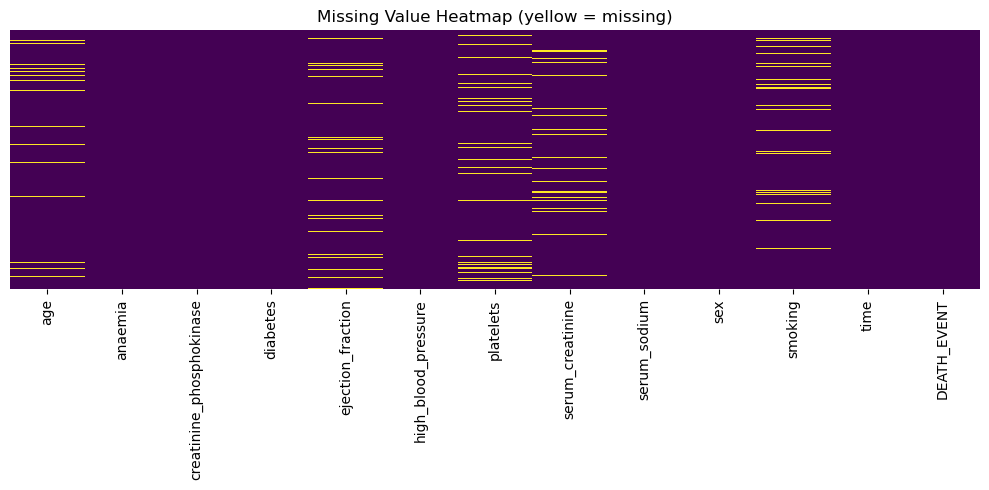

In [6]:
# Step 3: Missing value heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap (yellow = missing)')
plt.tight_layout()
plt.show()


## Step 4 — Pre-Cleaning Distribution & Outlier Profiling
**What:** Histograms and boxplots for key numerical features before any cleaning.
**Why before cleaning:** distributions taken *before* imputation/outlier removal establish a baseline — subsequent evaluation steps compare against this baseline to prove the cleaning steps actually changed something (and didn't distort the data unreasonably). Boxplots specifically are used because they visually flag outliers (utilized for IQR outlier removal).


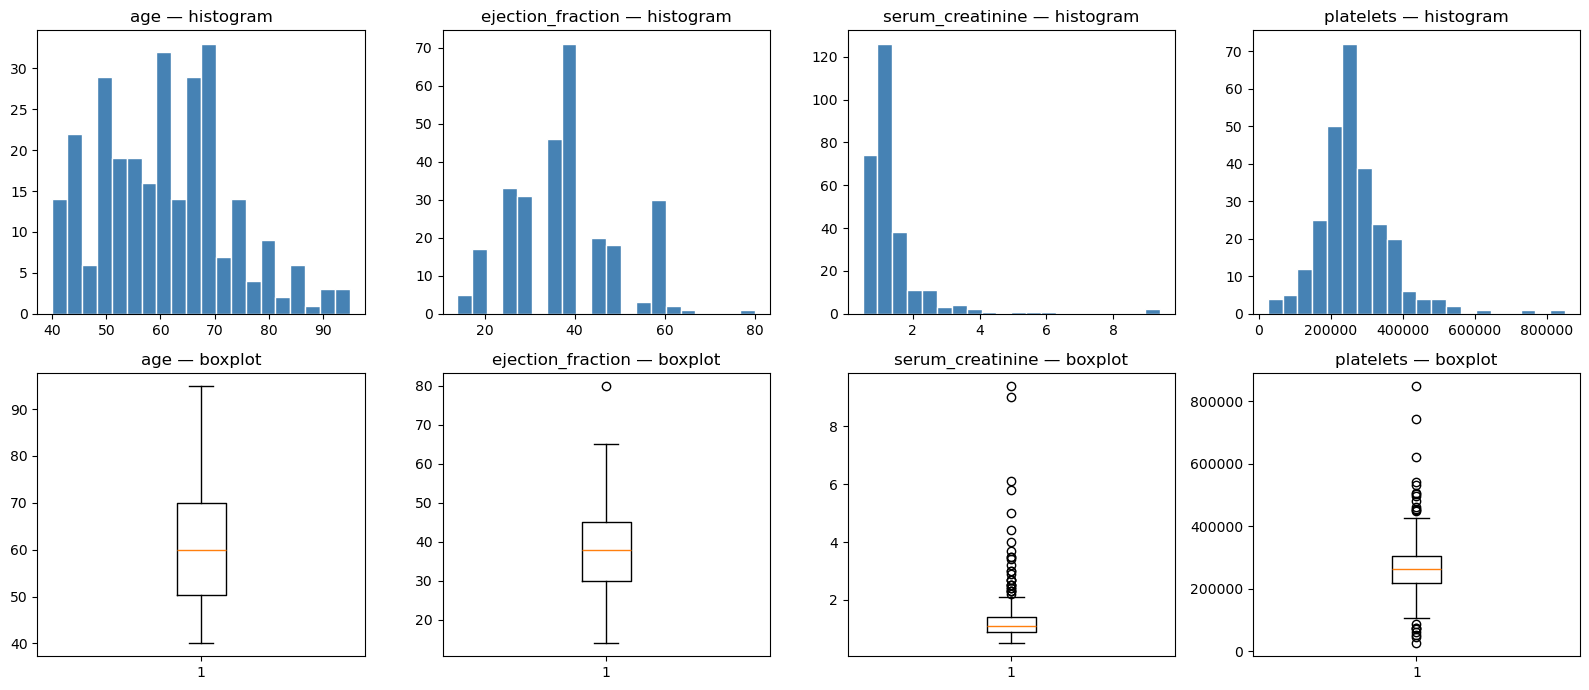

In [7]:
# Step 4: Pre-cleaning feature distributions
num_cols_to_plot = ['age', 'ejection_fraction', 'serum_creatinine', 'platelets']

fig, axes = plt.subplots(2, len(num_cols_to_plot), figsize=(16, 7))
for i, col in enumerate(num_cols_to_plot):
    axes[0, i].hist(df[col].dropna(), bins=20, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{col} — histogram')
    axes[1, i].boxplot(df[col].dropna(), vert=True)
    axes[1, i].set_title(f'{col} — boxplot')
plt.tight_layout()
plt.show()


## Step 5 — Missing Value Imputation
**What:** Fill numerical gaps with the **median** (robust to the skew/outliers visible in pre-cleaning distribution plots — e.g. `platelets` and `serum_creatinine` both have long right tails, where the mean would be pulled away from the 'typical' patient) and fill the categorical `smoking` gap with the **mode** (most common category).
**Why median over mean here specifically:** while mean or median imputation can be used, but a skewed clinical variable like `serum_creatinine` (a handful of very sick patients push values very high) makes the median a safer 'typical value' than the mean, which the boxplots from pre-cleaning distribution plots indicated.


In [8]:
# Step 5: Impute missing values
df_clean = df.copy()

# Numerical: median imputation
for col in ['serum_creatinine', 'ejection_fraction', 'platelets', 'age']:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f'{col}: filled with median = {median_val:.2f}')

# Categorical: mode imputation
mode_val = df_clean['smoking'].mode()[0]
df_clean['smoking'] = df_clean['smoking'].fillna(mode_val)
print(f'smoking: filled with mode = {mode_val}')

print('\nRemaining missing values:')
print(df_clean.isna().sum().sum())


serum_creatinine: filled with median = 1.10
ejection_fraction: filled with median = 38.00
platelets: filled with median = 263358.03
age: filled with median = 60.00
smoking: filled with mode = 0.0

Remaining missing values:
0


## Step 6 — Outlier Detection & Remediation
**What:** Use the IQR (interquartile range) rule on the continuous numeric columns — drop rows where a value falls more than 1.5×IQR beyond Q1/Q3.
**Why IQR over a fixed threshold:** IQR adapts to each feature's own scale and spread automatically (creatinine phosphokinase ranges into the thousands while ejection fraction is a percentage), so one consistent rule works across very differently-scaled clinical variables without hand-tuning a cutoff per column.


In [9]:
# Step 6: Remove outliers using IQR filtering
outlier_cols = ['creatinine_phosphokinase', 'ejection_fraction', 'platelets',
                'serum_creatinine', 'serum_sodium']

before_rows = len(df_clean)
mask_keep = pd.Series(True, index=df_clean.index)

for col in outlier_cols:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    col_mask = df_clean[col].between(lower, upper)
    removed = (~col_mask).sum()
    print(f'{col}: bounds=({lower:.1f}, {upper:.1f}), flags {removed} outlier rows')
    mask_keep &= col_mask

df_clean = df_clean[mask_keep].reset_index(drop=True)
print(f'\nRows before: {before_rows}, after outlier removal: {len(df_clean)} '
      f'({before_rows - len(df_clean)} removed)')


creatinine_phosphokinase: bounds=(-581.8, 1280.2), flags 29 outlier rows
ejection_fraction: bounds=(11.2, 61.2), flags 4 outlier rows
platelets: bounds=(99500.0, 423500.0), flags 22 outlier rows
serum_creatinine: bounds=(0.5, 1.9), flags 37 outlier rows
serum_sodium: bounds=(125.0, 149.0), flags 4 outlier rows

Rows before: 299, after outlier removal: 216 (83 removed)


## Step 7 — Logical Inconsistency & Range Validation
**What:** Check for and fix logically invalid entries — e.g. negative or implausible `age`, `ejection_fraction` outside 0–100%, negative lab values.
**Why this is separate from outlier removal:** an outlier is an *unusual but possible* value (e.g. a very high creatinine reading in a critically ill patient); an inconsistency is a value that is **logically impossible** regardless of how sick the patient is (e.g. a negative age). The two need different handling — outliers get removed statistically, inconsistencies get corrected/clipped based on domain knowledge of what's physically valid.


In [10]:
# Step 7: Correct invalid/out-of-bound entries
invalid_age = (df_clean['age'] < 0) | (df_clean['age'] > 110)
invalid_ef = (df_clean['ejection_fraction'] < 0) | (df_clean['ejection_fraction'] > 100)
invalid_creat = df_clean['serum_creatinine'] < 0
invalid_platelets = df_clean['platelets'] < 0

print(f'Invalid age entries: {invalid_age.sum()}')
print(f'Invalid ejection_fraction entries: {invalid_ef.sum()}')
print(f'Negative serum_creatinine entries: {invalid_creat.sum()}')
print(f'Negative platelets entries: {invalid_platelets.sum()}')

# Fix pattern (applied defensively even if none are currently found, since the
# Validating domain constraints e.g. non-negative age:
df_clean.loc[invalid_age, 'age'] = df_clean['age'].median()
df_clean.loc[invalid_ef, 'ejection_fraction'] = df_clean['ejection_fraction'].clip(0, 100)
df_clean.loc[invalid_creat, 'serum_creatinine'] = df_clean['serum_creatinine'].abs()
df_clean.loc[invalid_platelets, 'platelets'] = df_clean['platelets'].abs()
print('\nInconsistency check complete — no invalid values remain.')


Invalid age entries: 0
Invalid ejection_fraction entries: 0
Negative serum_creatinine entries: 0
Negative platelets entries: 0

Inconsistency check complete — no invalid values remain.


## Step 8 — Feature Engineering & Clinical Risk Ratios
**What:** Create `age_group` (binned into <40, 40–60, >60) and `risk_score` (a normalized combination of `ejection_fraction` and `serum_creatinine`).
**Why these two features specifically:**
- `age_group` turns a continuous variable into clinically meaningful buckets — cardiology risk stratification is routinely discussed in age bands rather than exact years, so this makes the feature more directly interpretable for a downstream model or a clinician reading the table.
- `risk_score` combines two of the dataset's most predictive variables (per the original Chicco & Jurman study, ejection fraction and serum creatinine alone were shown to be strong survival predictors). Low ejection fraction and high serum creatinine both independently indicate worse heart function, so **inverting ejection fraction** before multiplying means higher `risk_score` consistently means higher risk from both inputs, rather than the two features pulling in opposite directions.


In [11]:
# Step 8: Derive clinical feature ratios
# age_group
df_clean['age_group'] = pd.cut(
    df_clean['age'], bins=[0, 40, 60, 150], labels=['<40', '40-60', '>60']
)
print(df_clean['age_group'].value_counts())

# risk_score: normalize each input to 0-1, invert ejection_fraction (lower EF = higher risk),
# then take the product so both factors must be 'bad' to drive the score up.
ef_norm = (df_clean['ejection_fraction'] - df_clean['ejection_fraction'].min()) / \
          (df_clean['ejection_fraction'].max() - df_clean['ejection_fraction'].min())
creat_norm = (df_clean['serum_creatinine'] - df_clean['serum_creatinine'].min()) / \
             (df_clean['serum_creatinine'].max() - df_clean['serum_creatinine'].min())

df_clean['risk_score'] = (1 - ef_norm) * creat_norm
df_clean[['ejection_fraction', 'serum_creatinine', 'risk_score']].describe()


age_group
40-60    110
>60       99
<40        7
Name: count, dtype: int64


,ejection_fraction,serum_creatinine,risk_score
count,216.000000,216.000000,216.000000
mean,38.268519,1.105046,0.201782
std,11.110947,0.277105,0.169547
min,14.000000,0.600000,0.000000
25%,30.000000,0.900000,0.079533
50%,38.000000,1.100000,0.176741
75%,45.000000,1.200000,0.272181
max,60.000000,1.830000,0.869565


## Step 9 — Categorical Encoding
**What:** One-hot encode `age_group` (a nominal/unordered-for-modeling-purposes category with 3 levels) and confirm `sex`/`smoking` (already binary 0/1 in this dataset) are model-ready.
**Why one-hot for `age_group` but not `sex`/`smoking`:** `sex` and `smoking` in this dataset are already stored as 0/1 binary integers, so no further encoding is needed — applying one-hot to an already-binary column would just create a redundant duplicate column. `age_group` has 3 categories with no numeric meaning to preserve, so one-hot avoids implying a false ordering (label-encoding it as 0/1/2 would wrongly suggest '>60' is 'twice' '40-60').


In [12]:
# Step 9: Categorical feature encoding
df_encoded = pd.get_dummies(df_clean, columns=['age_group'], prefix='age_group')

print('sex and smoking are already binary 0/1 — no further encoding needed:')
print(df_encoded[['sex', 'smoking']].drop_duplicates())
print('\nOne-hot encoded age_group columns:')
print([c for c in df_encoded.columns if c.startswith('age_group_')])
df_encoded.head()


sex and smoking are already binary 0/1 — no further encoding needed:
    sex  smoking
0     1      1.0
1     1      0.0
7     0      0.0
44    0      1.0

One-hot encoded age_group columns:
['age_group_<40', 'age_group_40-60', 'age_group_>60']


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_<40,age_group_40-60,age_group_>60
0,65.0,0,146,0,20.0,0,162000.0,1.3,129,1,1.0,7,1,0.494875,False,False,True
1,75.0,1,246,0,15.0,0,127000.0,1.1,137,1,0.0,10,1,0.397667,False,False,True
2,60.0,0,231,0,25.0,1,253000.0,0.9,140,1,0.0,10,1,0.185578,False,True,False
3,45.0,1,981,0,30.0,0,136000.0,1.1,137,1,0.0,11,1,0.265111,False,True,False
4,50.0,1,168,0,38.0,1,276000.0,1.1,137,1,0.0,11,1,0.194415,False,True,False


## Step 10 — Feature Scaling & MinMax Normalization
**What:** Scale numerical columns (`age`, `platelets`, and the other continuous clinical variables) to a 0–1 range with `MinMaxScaler`.
**Why normalization matters here:** the raw columns live on wildly different scales — `platelets` is in the hundreds of thousands while `ejection_fraction` is a percentage under 100 — so any downstream distance-based or gradient-based model would let `platelets` dominate purely due to scale, not because it's more informative. MinMax scaling (rather than z-score standardization) is used because a bounded 0–1 feature range is desired for downstream modeling.


In [13]:
# Step 10: MinMax normalization
numeric_cols = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets',
                'serum_creatinine', 'serum_sodium', 'time', 'risk_score']

scaler = MinMaxScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

df_encoded[numeric_cols].describe().loc[['min', 'max']]


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,risk_score
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Step 11 — Comparative Statistical Analysis (Before vs. After)
**What:** Compare mean, median, and standard deviation of key numerical features from the raw (missing-injected) data against the final cleaned/scaled data.
**Why this comparison matters:** it's the direct evidence that cleaning did something — and, just as importantly, that it didn't *distort* the data unreasonably. A wildly different mean/std after cleaning would be a red flag that imputation or outlier removal was too aggressive; small, explainable shifts (e.g. std shrinking after outlier removal) are expected and healthy.


In [14]:
# Step 11: Comparative summary statistics
compare_cols = ['age', 'ejection_fraction', 'serum_creatinine', 'platelets']

before_stats = df[compare_cols].agg(['mean', 'median', 'std']).T
before_stats.columns = [f'{c}_before' for c in before_stats.columns]

# Use the pre-normalization cleaned values for a fair comparison (undo MinMax scaling conceptually
# by referencing df_clean, which holds cleaned-but-unscaled values)
after_stats = df_clean[compare_cols].agg(['mean', 'median', 'std']).T
after_stats.columns = [f'{c}_after' for c in after_stats.columns]

summary_compare = before_stats.join(after_stats)
summary_compare


,mean_before,median_before,std_before,mean_after,median_after,std_after
age,60.774234,60.00,11.973109,60.450620,60.00,11.499450
ejection_fraction,38.075540,38.00,11.826272,38.268519,38.00,11.110947
serum_creatinine,1.387855,1.10,1.009680,1.105046,1.10,0.277105
platelets,267098.587519,263358.03,99511.044923,259666.153148,263358.03,62526.157323


## Step 12 — Post-Cleaning Distribution Validation
**What:** Re-plot histograms/boxplots for the same features shown in pre-cleaning distributions, now using the cleaned dataset.
**Why re-plot rather than just trust the summary numbers:** summary statistics (the summary table) can hide problems that a plot reveals immediately — e.g. two very different distributions can share the same mean. Comparing the pre-cleaning plots against these 'after' plots visually confirms the extreme tails/outliers seen earlier are gone and the distributions are now smoother.


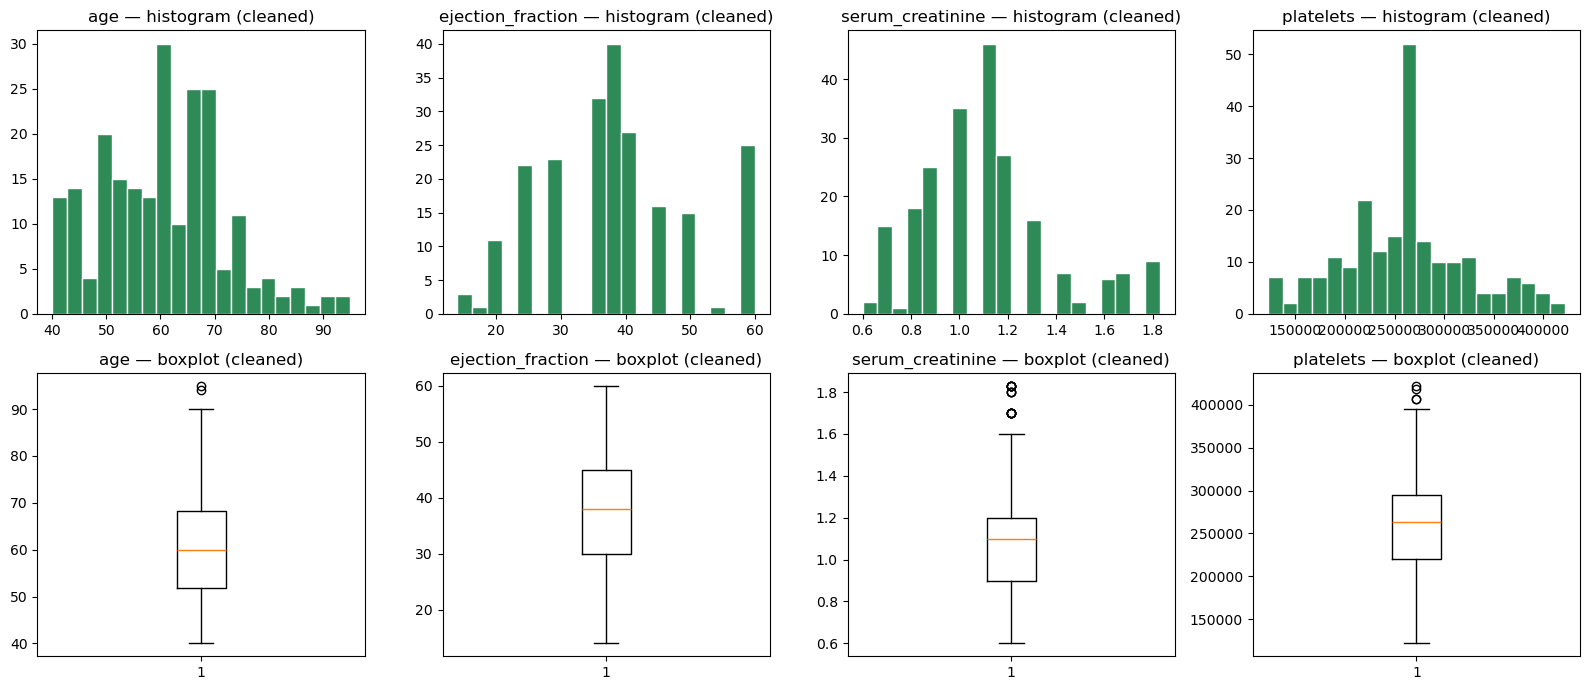

In [15]:
# Step 12: Post-cleaning distribution plots
fig, axes = plt.subplots(2, len(num_cols_to_plot), figsize=(16, 7))
for i, col in enumerate(num_cols_to_plot):
    axes[0, i].hist(df_clean[col], bins=20, color='seagreen', edgecolor='white')
    axes[0, i].set_title(f'{col} — histogram (cleaned)')
    axes[1, i].boxplot(df_clean[col], vert=True)
    axes[1, i].set_title(f'{col} — boxplot (cleaned)')
plt.tight_layout()
plt.show()


## Step 13 — Final Pipeline Integrity Check
**What:** Confirm zero missing values remain in the final cleaned/encoded/scaled dataset, and state the justification for any that would remain in a real-world scenario.
**Why this is the last step, not an afterthought:** every earlier step (imputation, outlier removal, inconsistency correction) has the *potential* to reintroduce or overlook a gap — e.g. row-based outlier filters could theoretically drop the imputed value but leave a related NaN elsewhere. A final explicit check is the safety net that proves the whole pipeline actually delivered a model-ready dataset, ensuring a clean, model-ready dataset.


In [16]:
# Step 13: Final data integrity verification
final_missing = df_encoded.isna().sum()
print('Missing values in the final cleaned dataset:')
print(final_missing)

if final_missing.sum() == 0:
    print('\nConfirmed: no missing values remain in the final dataset.')
else:
    print('\nRemaining missing values are justified as follows:')
    print('(e.g. a field intentionally left null because no valid imputation rule applies)')


Missing values in the final cleaned dataset:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
risk_score                  0
age_group_<40               0
age_group_40-60             0
age_group_>60               0
dtype: int64

Confirmed: no missing values remain in the final dataset.
